## Healthcare Data Preprocessing Project


In [113]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats

df = pd.read_csv('healthcare_dataset.csv')
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,58.0,Male,West,13.523761,183.467278,260.511249,125.251320,0
1,2,71.0,Female,NaN,27.174859,133.098817,291.901328,NaN,0
2,3,48.0,Male,North,28.428085,105.297829,161.048521,145.141478,1
3,4,34.0,Female,South,30.823143,116.664979,228.833726,90.851003,0
4,5,62.0,Female,South,NaN,146.774912,177.780598,104.217499,1


In [114]:
# Missing Value Summary (%)
missing = df.isnull().mean()*100
missing

patient_id         0.0
age               12.0
gender            32.8
region            24.4
bmi               12.0
blood_pressure     0.0
cholesterol       12.0
glucose           12.0
disease_risk       0.0
dtype: float64

In [115]:
# Simple Imputer Numerical (Mean)
df_mean = df.copy()
mean_imp = SimpleImputer(strategy='mean')
df_mean[['bmi']] = mean_imp.fit_transform(df_mean[['bmi']])

# Simple Imputer Numerical (Median)
df_median = df.copy()
median_imp = SimpleImputer(strategy='median')
df_median[['bmi']] = median_imp.fit_transform(df_median[['bmi']])
df

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,58.0,Male,West,13.523761,183.467278,260.511249,125.251320,0
1,2,71.0,Female,NaN,27.174859,133.098817,291.901328,NaN,0
2,3,48.0,Male,North,28.428085,105.297829,161.048521,145.141478,1
3,4,34.0,Female,South,30.823143,116.664979,228.833726,90.851003,0
4,5,62.0,Female,South,NaN,146.774912,177.780598,104.217499,1
...,...,...,...,...,...,...,...,...,...
245,246,NaN,Male,West,36.320969,130.542123,NaN,132.247236,0
246,247,NaN,Female,West,26.103300,130.140440,NaN,149.369880,0
247,248,51.0,NaN,NaN,NaN,137.875175,143.976665,142.506770,1
248,249,43.0,NaN,North,24.458634,132.560416,262.815208,109.679028,1


In [116]:
# Simple Imputer Categorical (Region)
cat_imp = SimpleImputer(strategy='most_frequent')
df_mean[['region']] = cat_imp.fit_transform(df_mean[['region']])
df

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,58.0,Male,West,13.523761,183.467278,260.511249,125.251320,0
1,2,71.0,Female,NaN,27.174859,133.098817,291.901328,NaN,0
2,3,48.0,Male,North,28.428085,105.297829,161.048521,145.141478,1
3,4,34.0,Female,South,30.823143,116.664979,228.833726,90.851003,0
4,5,62.0,Female,South,NaN,146.774912,177.780598,104.217499,1
...,...,...,...,...,...,...,...,...,...
245,246,NaN,Male,West,36.320969,130.542123,NaN,132.247236,0
246,247,NaN,Female,West,26.103300,130.140440,NaN,149.369880,0
247,248,51.0,NaN,NaN,NaN,137.875175,143.976665,142.506770,1
248,249,43.0,NaN,North,24.458634,132.560416,262.815208,109.679028,1


In [117]:
# Most Frequent Imputation (Gender)
df_mean[['gender']] = cat_imp.fit_transform(df_mean[['gender']])
df

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,58.0,Male,West,13.523761,183.467278,260.511249,125.251320,0
1,2,71.0,Female,NaN,27.174859,133.098817,291.901328,NaN,0
2,3,48.0,Male,North,28.428085,105.297829,161.048521,145.141478,1
3,4,34.0,Female,South,30.823143,116.664979,228.833726,90.851003,0
4,5,62.0,Female,South,NaN,146.774912,177.780598,104.217499,1
...,...,...,...,...,...,...,...,...,...
245,246,NaN,Male,West,36.320969,130.542123,NaN,132.247236,0
246,247,NaN,Female,West,26.103300,130.140440,NaN,149.369880,0
247,248,51.0,NaN,NaN,NaN,137.875175,143.976665,142.506770,1
248,249,43.0,NaN,North,24.458634,132.560416,262.815208,109.679028,1


In [118]:
# Missing Indicator + Random Sample

df_rand = df.copy()

for col in ['age', 'bmi']:
    df_rand[col + '_missing'] = df_rand[col].isnull().astype(int)
    
    random_samples = df_rand[col].dropna().sample(df_rand[col].isnull().sum(), replace=True)
    
    df_rand.loc[df_rand[col].isnull(), col] = random_samples.values

df_rand.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing,bmi_missing
0,1,58.0,Male,West,13.523761,183.467278,260.511249,125.251320,0,0,0
1,2,71.0,Female,NaN,27.174859,133.098817,291.901328,NaN,0,0,0
2,3,48.0,Male,North,28.428085,105.297829,161.048521,145.141478,1,0,0
3,4,34.0,Female,South,30.823143,116.664979,228.833726,90.851003,0,0,0
4,5,62.0,Female,South,18.165150,146.774912,177.780598,104.217499,1,0,1


In [119]:
# KNN Imputer
df_knn = df.copy()
knn = KNNImputer(n_neighbors=5)
df_knn[['age','bmi','cholesterol','glucose']] = knn.fit_transform(df_knn[['age','bmi','cholesterol','glucose']])
print("KNN Missing Values:\n", df_knn.isnull().sum())

KNN Missing Values:
 patient_id         0
age                0
gender            82
region            61
bmi                0
blood_pressure     0
cholesterol        0
glucose            0
disease_risk       0
dtype: int64


In [120]:
# MICE (Iterative Imputer)
df_mice = df.copy()
mice = IterativeImputer(random_state=0)
df_mice[['age','bmi','cholesterol','glucose']] = mice.fit_transform(df_mice[['age','bmi','cholesterol','glucose']])
print("MICE Missing Values:\n", df_mice.isnull().sum())

MICE Missing Values:
 patient_id         0
age                0
gender            82
region            61
bmi                0
blood_pressure     0
cholesterol        0
glucose            0
disease_risk       0
dtype: int64


In [121]:
# Z-score FIXED (column-wise safer filtering)

num_cols = df_mean.select_dtypes(include=np.number).columns

z = np.abs(stats.zscore(df_mean[num_cols]))

df_z = df_mean[(z < 3).sum(axis=1) >= len(num_cols) - 1]

df_z.shape

(0, 9)

In [122]:
# IQR Method

df_iqr = df_mean.copy()

num_cols = df_iqr.select_dtypes(include=np.number).columns

Q1 = df_iqr[num_cols].quantile(0.25)
Q3 = df_iqr[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_iqr = df_iqr[
    ~((df_iqr[num_cols] < (Q1 - 1.5 * IQR)) |
      (df_iqr[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

df_iqr.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,58.0,Male,West,13.523761,183.467278,260.511249,125.251320,0
1,2,71.0,Female,West,27.174859,133.098817,291.901328,NaN,0
2,3,48.0,Male,North,28.428085,105.297829,161.048521,145.141478,1
3,4,34.0,Female,South,30.823143,116.664979,228.833726,90.851003,0
4,5,62.0,Female,South,27.288364,146.774912,177.780598,104.217499,1


In [123]:
# Percentile Method
df_pct = df_mean.copy()
for col in ['bmi','blood_pressure','cholesterol','glucose']:
    lower = df_pct[col].quantile(0.01)
    upper = df_pct[col].quantile(0.99)
    df_pct[col] = df_pct[col].clip(lower, upper)
print("Percentile Method Applied")
print(df_pct.describe())

Percentile Method Applied
       patient_id         age         bmi  blood_pressure  cholesterol  \
count  250.000000  220.000000  250.000000      250.000000   220.000000   
mean   125.500000   49.904545   27.158207      123.343238   202.202311   
std     72.312977   17.397711   10.836894       39.039865    53.984511   
min      1.000000   20.000000   10.272696       59.292115    74.973606   
25%     63.250000   34.000000   22.348655       99.664355   165.713261   
50%    125.500000   51.000000   26.528900      119.813356   201.018016   
75%    187.750000   63.000000   29.413521      137.865129   236.687792   
max    250.000000   79.000000   83.326313      301.328604   347.535881   

          glucose  disease_risk  
count  220.000000    250.000000  
mean    97.948077      0.512000  
std     34.833111      0.500859  
min     19.580657      0.000000  
25%     73.692441      0.000000  
50%     99.128047      1.000000  
75%    120.202017      1.000000  
max    179.665063      1.000000  


In [124]:
# Winsorization
from scipy.stats.mstats import winsorize
df_win = df_mean.copy()
for col in ['bmi','blood_pressure','cholesterol','glucose']:
    df_win[col] = winsorize(df_win[col], limits=[0.05,0.05])
print("Winsorization Applied")
print(df_win.describe())

Winsorization Applied
       patient_id         age         bmi  blood_pressure  cholesterol  \
count  250.000000  220.000000  250.000000      250.000000   220.000000   
mean   125.500000   49.904545   26.019461      120.627478   203.560432   
std     72.312977   17.397711    5.995473       27.639277    52.676351   
min      1.000000   20.000000   14.614761       76.160657   113.510345   
25%     63.250000   34.000000   22.348655       99.664355   165.713261   
50%    125.500000   51.000000   26.528900      119.813356   201.018016   
75%    187.750000   63.000000   29.413521      137.865129   236.687792   
max    250.000000   79.000000   39.245976      183.467278   377.900621   

          glucose  disease_risk  
count  220.000000    250.000000  
mean    98.729517      0.512000  
std     33.531015      0.500859  
min     43.964325      0.000000  
25%     73.692441      0.000000  
50%     99.128047      1.000000  
75%    120.202017      1.000000  
max    186.270717      1.000000  


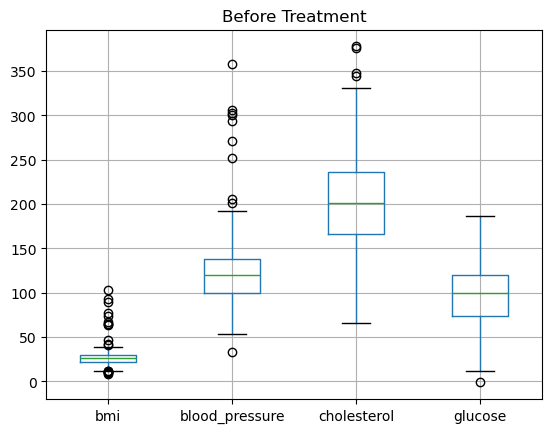

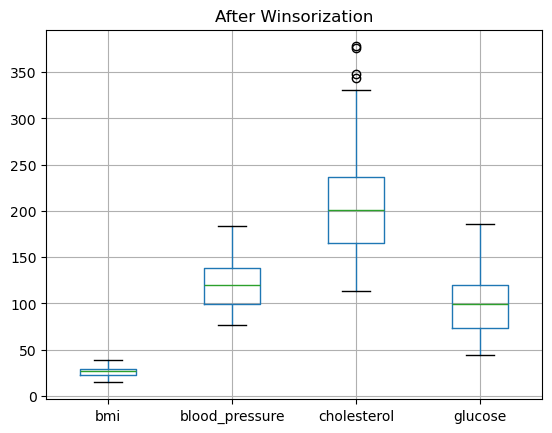

In [125]:
plt.figure()
df_mean[['bmi','blood_pressure','cholesterol','glucose']].boxplot()
plt.title("Before Treatment")
plt.show()

plt.figure()
df_win[['bmi','blood_pressure','cholesterol','glucose']].boxplot()
plt.title("After Winsorization")
plt.show()

In [126]:
# Comparison
print('Original:', df.shape)
print('Z-score:', df_z.shape)
print('IQR:', df_iqr.shape)
print('Percentile:', df_pct.shape)
print('Winsorization:', df_win.shape)

Original: (250, 9)
Z-score: (0, 9)
IQR: (218, 9)
Percentile: (250, 9)
Winsorization: (250, 9)


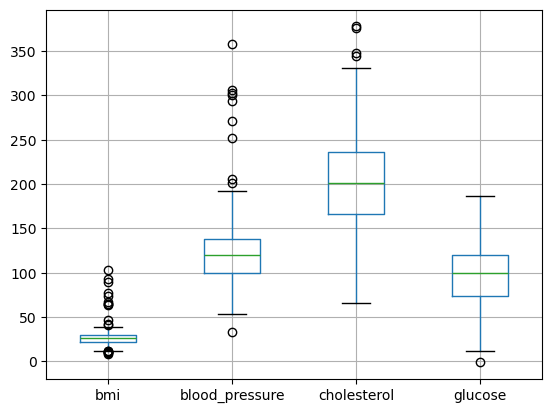

In [127]:
# Visualization
plt.figure()
df_mean[['bmi','blood_pressure','cholesterol','glucose']].boxplot()
plt.show()